<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e7/Neural_Network_-_basic_scheme_with_legends.png" 
   width="750" height="200" style="margin: 5px auto; display: block; position: relative; left: -10px; bottom: 10px" />
</div>



## Submodule -1.6 : Neural Netwok Architectures

## Table of Contents
####  1.  [Handcoded 2D Convolution in PyTorch](#Handcoded-2D-Convolution-in-PyTorch)
####  2.  [Handcoded 2D Convolution in TensorFlow](#Handcoded-2D-Convolution-in-TensorFlow)
####  3.  [Vanilla Convolution using PyTorch API](#Vanilla-Convolution-using-PyTorch-API)
####  4.  [Vanilla Convolution using TF2.0 API](#Vanilla-Convolution-using-TF2-API)
####  5.  [Padding in PyTorch](#Padding-in-PyTorch)
####  6.  [Padding in TF2.0](#Padding-in-TF2)
####  7.  [Striding in PyTorch](#Striding-in-PyTorch)
####  8.  [Striding in TF2.0](#Striding-in-TF2)
####  9.  [Max Pooling in PyTorch](#Max-Pooling-in-PyTorch)
#### 10. [Max Pooling in TF2.0](#Max-Pooling-in-TF2)
#### 11. [Max Pooling + Stride in PyTorch](#Max-Pooling-+-Stride-in-PyTorch)
#### 12. [Max Pooling + Stride in TF2.0](#Max-Pooling-+-Stride-in-TF2)
#### 13. [Vanishing and Exploding Gradient](#Vanishing-and-Exploding-Gradient)
#### 14. [Max Pooling + Stride](#Max-Pooling-+-Stride)
#### 15. [RNN for Sine Wave in PyTorch](#RNN-for-Sine-Wave-in-PyTorch)
#### 16. [LSTM for Sine Wave in TensorFlow](#LSTM-for-Sine-Wave-in-TensorFlow)
#### 17. [LSTM for Sine wave in TensorFlow using TimeSerisGenerator](#LSTM-for-Sine-wave-in-TensorFlow-using-TimeSerisGenerator)


# Handcoded 2D Convolution in PyTorch

In [1]:
# Display matplotlib plots inside Jupyter Notebook
%matplotlib inline

# Import required libraries
import torch
from matplotlib import pyplot as plt
import torch.nn as nn


# Custom 2D Convolution layer implemented using PyTorch
class Conv2D_PyT(nn.Module):
    
    def __init__(self, kernel):
        """
        Initialize the convolution layer.

        Parameters
        ----------
        kernel : torch.Tensor
            Convolution kernel (filter) used for the operation
        """
        super().__init__()

        # Register kernel as a learnable parameter
        self.weight = nn.Parameter(kernel)

    
    def conv(self, x, k):
        """
        Perform manual 2D convolution.

        Parameters
        ----------
        x : torch.Tensor
            Input matrix
        k : torch.Tensor
            Convolution kernel

        Returns
        -------
        torch.Tensor
            Convolved output
        """

        # Kernel dimensions
        r, c = k.shape

        # Output dimensions
        # (input_height - kernel_height + 1, input_width - kernel_width + 1)
        out_rows = x.shape[0] - r + 1
        out_cols = x.shape[1] - c + 1

        # Initialize output tensor
        y = torch.zeros((out_rows, out_cols))

        # Slide kernel over input
        for i in range(out_rows):
            for j in range(out_cols):

                # Extract the current region of the input
                region = x[i:i+r, j:j+c]

                # Element-wise multiplication and sum
                y[i, j] = (region * k).sum()

        return y


    def forward(self, x):
        """
        Forward pass of the layer.
        """
        return self.conv(x, self.weight)


# -------------------------------
# Example usage
# -------------------------------

# Input matrix
x = torch.tensor([
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8]
], dtype=torch.float32)

# Convolution kernel
k = torch.tensor([
    [0.0, 1.0],
    [2.0, 3.0]
])

# Create convolution model
model = Conv2D_PyT(k)

# Perform convolution
y = model(x)

# Print result
print("Convolution Output in Torch:")
print(y.detach().numpy())

Convolution Output in Torch:
[[19. 25.]
 [37. 43.]]


# Handcoded 2D Convolution in TensorFlow

In [2]:
import tensorflow as tf


# Custom 2D Convolution layer implemented using TensorFlow
class Conv2D_TF(tf.keras.layers.Layer):

    def __init__(self, kernel):
        """
        Initialize the custom convolution layer.

        Parameters
        ----------
        kernel : tf.Tensor
            Convolution kernel (filter)
        """
        super().__init__()

        # Store kernel and register it as a trainable variable
        self.kernel = kernel
        self.weight = tf.Variable(self.kernel, trainable=True)


    def conv(self, x):
        """
        Perform manual 2D convolution.

        Parameters
        ----------
        x : tf.Tensor
            Input matrix

        Returns
        -------
        tf.Tensor
            Convolved output
        """

        # Kernel dimensions
        r, c = self.weight.shape

        # Output dimensions
        # (input_height - kernel_height + 1, input_width - kernel_width + 1)
        out_rows = x.shape[0] - r + 1
        out_cols = x.shape[1] - c + 1

        # Initialize output tensor
        y = tf.Variable(tf.zeros((out_rows, out_cols)))

        # Slide kernel over input
        for i in range(out_rows):
            for j in range(out_cols):

                # Extract current region from input
                region = x[i:i+r, j:j+c]

                # Element-wise multiplication
                temp = tf.math.multiply(region, self.weight)

                # Store sum of multiplied values
                y[i, j].assign(tf.reduce_sum(temp))

        return y


    def call(self, inputs):
        """
        Forward pass of the custom layer.
        """
        return self.conv(inputs)


# -------------------------------
# Example usage
# -------------------------------

# Input matrix
x = tf.constant([
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8]
], dtype=tf.float32)

# Convolution kernel
k = tf.constant([
    [0.0, 1.0],
    [2.0, 3.0]
], dtype=tf.float32)

# Create convolution layer
model = Conv2D_TF(k)

# Perform convolution
output = model(x)

# Print result
print("Convolution Output in TensorFlow:")
print(output.numpy())

2026-03-07 14:37:50.936970: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Convolution Output in TensorFlow:
[[19. 25.]
 [37. 43.]]


# Handcoded 2D Convolution in JAX


In [3]:
# Import required libraries
import jax
import jax.numpy as jnp
import numpy as np


# Custom 2D Convolution implementation using JAX
class Conv2D_JAX:
    
    def __init__(self, kernel):
        """
        Initialize the convolution layer.

        Parameters
        ----------
        kernel : jnp.ndarray
            Convolution kernel (filter)
        """
        # Store the kernel
        self.kernel = kernel


    def conv(self, x):
        """
        Perform manual 2D convolution.

        Parameters
        ----------
        x : jnp.ndarray
            Input matrix

        Returns
        -------
        np.ndarray
            Convolved output
        """

        # Kernel dimensions
        r, c = self.kernel.shape

        # Output dimensions
        # (input_height - kernel_height + 1, input_width - kernel_width + 1)
        out_rows = x.shape[0] - r + 1
        out_cols = x.shape[1] - c + 1

        # Initialize output array
        y = np.zeros((out_rows, out_cols))

        # Slide kernel over input
        for i in range(out_rows):
            for j in range(out_cols):

                # Extract current region from input
                region = x[i:i+r, j:j+c]

                # Element-wise multiplication
                temp = jnp.multiply(region, self.kernel)

                # Sum of multiplied values
                y[i, j] = jnp.sum(temp)

        return y


# -------------------------------
# Example usage
# -------------------------------

# Input matrix
x = jnp.array([
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8]
], dtype=jnp.float32)

# Convolution kernel
k = jnp.array([
    [0.0, 1.0],
    [2.0, 3.0]
], dtype=jnp.float32)

# Create convolution model
model = Conv2D_JAX(k)

# Perform convolution
y = model.conv(x)

# Print result
print("Convolution Output in JAX:")
print(y)

Convolution Output in JAX:
[[19. 25.]
 [37. 43.]]


# Vanilla Convolution using PyTorch API


In [4]:
# Import required libraries
import torch
import torch.nn as nn
import numpy as np


# ------------------------------------------------
# Input Data Characteristics
# ------------------------------------------------
n_batch = 1      # number of images in the batch
n_channel = 1    # number of channels (grayscale image)
n_row = 3        # image height
n_col = 3        # image width


# ------------------------------------------------
# Create Input Tensor
# Shape required by Conv2D in PyTorch:
# (batch_size, channels, height, width)
# ------------------------------------------------
x = torch.zeros(n_batch, n_channel, n_row, n_col)

# Assign values to the image
x[0, 0] = torch.tensor([
    [0.0, 1.0, 2.0],
    [3.0, 4.0, 5.0],
    [6.0, 7.0, 8.0]
])


# ------------------------------------------------
# Define Convolution Layer
# ------------------------------------------------
conv_layer = nn.Conv2d(
    in_channels=n_channel,
    out_channels=n_channel,
    kernel_size=2,
    stride=1
)


# ------------------------------------------------
# User-Defined Convolution Kernel
# ------------------------------------------------
kernel = torch.tensor([
    [0.0, 1.0],
    [2.0, 3.0]
])

# Reshape kernel to match PyTorch format:
# (out_channels, in_channels, height, width)
kernel = kernel.unsqueeze(0).unsqueeze(0)


# ------------------------------------------------
# Replace Layer Parameters with Custom Kernel
# ------------------------------------------------
conv_layer.weight = nn.Parameter(kernel)

# Set bias to zero
conv_layer.bias = nn.Parameter(torch.tensor([0.0]))


# ------------------------------------------------
# Perform Convolution
# ------------------------------------------------
y = conv_layer(x)


# ------------------------------------------------
# Display Output
# ------------------------------------------------
print("Convolved Output y:")
print(y.detach().numpy()[0, 0])

Convolved Output y:
[[19. 25.]
 [37. 43.]]


# Vanilla Convolution using TF2 API


In [5]:
# Import required libraries
import tensorflow as tf
import numpy as np


# ------------------------------------------------
# Input Data Preparation
# ------------------------------------------------
# TensorFlow Conv2D expects input shape:
# (batch_size, height, width, channels)

# Original 2D image
x = np.array([
    [0.0, 1.0, 2.0],
    [3.0, 4.0, 5.0],
    [6.0, 7.0, 8.0]
])

# Add batch dimension: (1, 3, 3)
x = np.expand_dims(x, axis=0)

# Add channel dimension: (1, 3, 3, 1)
x = np.expand_dims(x, axis=-1)


# ------------------------------------------------
# Custom Kernel Initializer
# ------------------------------------------------
# This function initializes the convolution kernel
# with a user-defined 2×2 filter
def kernel_initializer(shape, dtype=None):

    # Create empty kernel tensor
    kernel = np.zeros(shape)

    # Assign custom kernel values
    # TensorFlow kernel format:
    # (kernel_height, kernel_width, in_channels, out_channels)
    kernel[:, :, 0, 0] = np.array([
        [0, 1],
        [2, 3]
    ])

    return kernel


# ------------------------------------------------
# Define Convolution Layer
# ------------------------------------------------
conv_layer = tf.keras.layers.Conv2D(
    filters=1,                # number of output channels
    kernel_size=2,            # 2×2 kernel
    activation=None,
    kernel_initializer=kernel_initializer
)


# ------------------------------------------------
# Perform Convolution
# ------------------------------------------------
y = conv_layer(x)


# ------------------------------------------------
# Display Output
# ------------------------------------------------
print("Convolved Output y in TensorFlow 2:")
print(y.numpy()[0, :, :, 0])

Convolved Output y in TensorFlow 2:
[[19. 25.]
 [37. 43.]]


# Padding in PyTorch


In [6]:
# Import required libraries
import torch
import torch.nn as nn
import numpy as np


# ------------------------------------------------
# Input Data Characteristics
# ------------------------------------------------
n_batch = 1      # number of images in the batch
n_channel = 1    # number of channels (grayscale image)
n_row = 3        # image height
n_col = 3        # image width


# ------------------------------------------------
# Create Input Tensor
# PyTorch Conv2D expects input shape:
# (batch_size, channels, height, width)
# ------------------------------------------------
x = torch.zeros(n_batch, n_channel, n_row, n_col)

# Assign values to the input image
x[0, 0] = torch.tensor([
    [0.0, 1.0, 2.0],
    [3.0, 4.0, 5.0],
    [6.0, 7.0, 8.0]
])


# ------------------------------------------------
# Define Convolution Layer
# padding=1 adds a border of zeros around the input
# ------------------------------------------------
conv_layer = nn.Conv2d(
    in_channels=n_channel,
    out_channels=n_channel,
    kernel_size=2,
    stride=1,
    padding=1
)


# ------------------------------------------------
# Define User-Specified Kernel
# PyTorch kernel shape:
# (out_channels, in_channels, kernel_height, kernel_width)
# ------------------------------------------------
kernel = torch.tensor([
    [0.0, 1.0],
    [2.0, 3.0]
]).unsqueeze(0).unsqueeze(0)


# ------------------------------------------------
# Replace Layer Weights and Bias
# ------------------------------------------------
conv_layer.weight = nn.Parameter(kernel)

# Set bias to zero
conv_layer.bias = nn.Parameter(torch.tensor([0.0]))


# ------------------------------------------------
# Perform Convolution with Padding
# ------------------------------------------------
y = conv_layer(x)


# ------------------------------------------------
# Display Output
# ------------------------------------------------
print("Convolved + Padded Output y:")
print(y.detach().numpy()[0, 0])

Convolved + Padded Output y:
[[ 0.  3.  8.  4.]
 [ 9. 19. 25. 10.]
 [21. 37. 43. 16.]
 [ 6.  7.  8.  0.]]


# Padding in TF2


In [7]:
# Import required libraries
import tensorflow as tf
import numpy as np


# ------------------------------------------------
# Input Data Preparation
# TensorFlow Conv2D expects input shape:
# (batch_size, height, width, channels)
# ------------------------------------------------

# Original 2D image
x = np.array([
    [0.0, 1.0, 2.0],
    [3.0, 4.0, 5.0],
    [6.0, 7.0, 8.0]
])

# Add batch dimension → (1, 3, 3)
x = np.expand_dims(x, axis=0)

# Add channel dimension → (1, 3, 3, 1)
x = np.expand_dims(x, axis=-1)


# ------------------------------------------------
# Custom Kernel Initializer
# This defines a user-specified 2×2 kernel
# ------------------------------------------------
def kernel_initializer(shape, dtype=None):

    # Create empty kernel tensor
    kernel = np.zeros(shape)

    # TensorFlow kernel format:
    # (kernel_height, kernel_width, in_channels, out_channels)
    kernel[:, :, 0, 0] = np.array([
        [0, 1],
        [2, 3]
    ])

    return kernel


# ------------------------------------------------
# Apply Zero Padding
# Adds a border of zeros around the image
# padding=(1,1) adds 1 row/column on all sides
# ------------------------------------------------
padded_x = tf.keras.layers.ZeroPadding2D(padding=(1, 1))(x)


# ------------------------------------------------
# Define Convolution Layer
# padding='valid' means no additional padding
# (since we already padded manually)
# ------------------------------------------------
conv_layer = tf.keras.layers.Conv2D(
    filters=1,                # number of output feature maps
    kernel_size=2,            # 2×2 kernel
    strides=(1, 1),
    padding='valid',
    activation=None,
    kernel_initializer=kernel_initializer
)


# ------------------------------------------------
# Perform Convolution
# ------------------------------------------------
y = conv_layer(padded_x)


# ------------------------------------------------
# Display Output
# ------------------------------------------------
print("Convolved + Padded Output y in TensorFlow 2:")
print(y.numpy()[0, :, :, 0])

Convolved + Padded Output y in TensorFlow 2:
[[ 0.  3.  8.  4.]
 [ 9. 19. 25. 10.]
 [21. 37. 43. 16.]
 [ 6.  7.  8.  0.]]


# No padding in JAX



In [8]:
# Import required libraries
import haiku as hk
import jax
import jax.numpy as jnp
import numpy as np


# ------------------------------------------------
# Define CNN Module
# ------------------------------------------------
class CNN(hk.Module):
    def __init__(self):
        """
        A simple CNN module with one 2D convolution layer.
        """
        super().__init__(name="CNN")

        # Haiku Conv2D expects input in NHWC format:
        # (batch_size, height, width, channels)
        self.conv = hk.Conv2D(
            output_channels=1,
            kernel_shape=(2, 2),
            padding="VALID"   # no padding
        )

    def __call__(self, x):
        """
        Forward pass through the convolution layer.
        """
        return self.conv(x)


# ------------------------------------------------
# Define Forward Function
# ------------------------------------------------
def conv_net_fn(x):
    """
    Build and apply the CNN model.
    """
    model = CNN()
    return model(x)


# ------------------------------------------------
# Prepare Input Data
# Input format: NHWC
# N = batch size
# H = height
# W = width
# C = channels
# ------------------------------------------------
x = np.array([
    [0.0, 1.0, 2.0],
    [3.0, 4.0, 5.0],
    [6.0, 7.0, 8.0]
], dtype=np.float32)

# Add batch dimension -> (1, 3, 3)
x = np.expand_dims(x, axis=0)

# Add channel dimension -> (1, 3, 3, 1)
x = np.expand_dims(x, axis=-1)


# ------------------------------------------------
# Define User-Specified Kernel
# Haiku kernel format:
# (kernel_height, kernel_width, input_channels, output_channels)
# ------------------------------------------------
kernel = np.array([
    [0.0, 1.0],
    [2.0, 3.0]
], dtype=np.float32)

kernel = np.expand_dims(kernel, axis=-1)  # -> (2, 2, 1)
kernel = np.expand_dims(kernel, axis=-1)  # -> (2, 2, 1, 1)


# ------------------------------------------------
# Initialize Haiku Model
# ------------------------------------------------
rng = jax.random.PRNGKey(42)

# Transform the forward function into init/apply functions
conv_net = hk.transform(conv_net_fn)

# Initialize model parameters
params = conv_net.init(rng, x)


# ------------------------------------------------
# Replace Randomly Initialized Weights with Custom Kernel
# ------------------------------------------------
for layer_name in params:
    params[layer_name]["w"] = jnp.array(kernel)
    params[layer_name]["b"] = jnp.zeros((1,), dtype=jnp.float32)


# ------------------------------------------------
# Perform Convolution
# ------------------------------------------------
output = conv_net.apply(params, rng, x).squeeze()


# ------------------------------------------------
# Display Output
# ------------------------------------------------
print("Convolved and No-Padded Output y in JAX:")
print(output)

/Users/raj/opt/anaconda3/lib/python3.8/site-packages/haiku/_src/data_structures.py:37: FutureWarning: jax.tree_structure is deprecated, and will be removed in a future release. Use jax.tree_util.tree_structure instead.
  PyTreeDef = type(jax.tree_structure(None))


Convolved and No-Padded Output y in JAX:
[[19. 25.]
 [37. 43.]]


/Users/raj/opt/anaconda3/lib/python3.8/site-packages/haiku/_src/data_structures.py:141: FutureWarning: jax.tree_flatten is deprecated, and will be removed in a future release. Use jax.tree_util.tree_flatten instead.
  leaves, treedef = jax.tree_flatten(tree)
/Users/raj/opt/anaconda3/lib/python3.8/site-packages/haiku/_src/data_structures.py:142: FutureWarning: jax.tree_unflatten is deprecated, and will be removed in a future release. Use jax.tree_util.tree_unflatten instead.
  return jax.tree_unflatten(treedef, leaves)


# Padding in JAX


In [10]:
# Import required libraries
import haiku as hk
import jax
import jax.numpy as jnp
import numpy as np


# ------------------------------------------------
# Define CNN Module
# ------------------------------------------------
class CNN(hk.Module):
    def __init__(self):
        """
        Simple CNN with one convolution layer.
        """
        super().__init__(name="CNN")

        # Conv2D layer
        # padding=(2,2) pads height and width with 2 pixels
        self.conv = hk.Conv2D(
            output_channels=1,
            kernel_shape=(2, 2),
            stride=(1, 1),
            padding=(2, 2)
        )

    def __call__(self, x):
        """
        Forward pass through convolution layer.
        """
        return self.conv(x)


# ------------------------------------------------
# Define Forward Function
# ------------------------------------------------
def conv_net_fn(x):
    """
    Builds and applies the CNN model.
    """
    model = CNN()
    return model(x)


# ------------------------------------------------
# Prepare Input Data (NHWC format)
# N = batch, H = height, W = width, C = channels
# ------------------------------------------------
x = np.array([
    [0.0, 1.0, 2.0],
    [3.0, 4.0, 5.0],
    [6.0, 7.0, 8.0]
], dtype=np.float32)

# Add batch dimension: (1, 3, 3)
x = np.expand_dims(x, axis=0)

# Add channel dimension: (1, 3, 3, 1)
x = np.expand_dims(x, axis=-1)


# ------------------------------------------------
# Define Custom Kernel
# Kernel format in Haiku:
# (kernel_height, kernel_width, in_channels, out_channels)
# ------------------------------------------------
kernel = np.array([
    [0.0, 1.0],
    [2.0, 3.0]
], dtype=np.float32)

kernel = np.expand_dims(kernel, axis=-1)  # (2,2,1)
kernel = np.expand_dims(kernel, axis=-1)  # (2,2,1,1)


# ------------------------------------------------
# Initialize Haiku Model
# ------------------------------------------------
rng = jax.random.PRNGKey(42)

conv_net = hk.transform(conv_net_fn)

# Initialize parameters
params = conv_net.init(rng, x)


# ------------------------------------------------
# Replace Randomly Initialized Weights
# ------------------------------------------------
for layer_name in params:
    params[layer_name]["w"] = jnp.array(kernel)
    params[layer_name]["b"] = jnp.zeros((1,), dtype=jnp.float32)


# ------------------------------------------------
# Perform Convolution
# ------------------------------------------------
output = conv_net.apply(params, rng, x).squeeze()


# Remove extra padded borders to match expected output
output = output[1:-1, 1:-1]


# ------------------------------------------------
# Display Output
# ------------------------------------------------
print("Convolved + Padded Output y in JAX:")
print(output)

Convolved + Padded Output y in JAX:
[[ 0.  3.  8.  4.]
 [ 9. 19. 25. 10.]
 [21. 37. 43. 16.]
 [ 6.  7.  8.  0.]]


# Striding in PyTorch

In [11]:
# Import required libraries
import torch
import torch.nn as nn
import numpy as np


# ------------------------------------------------
# Input Data Characteristics
# ------------------------------------------------
n_batch = 1      # number of images in the batch
n_channel = 1    # number of channels (grayscale)
n_row = 3        # image height
n_col = 3        # image width


# ------------------------------------------------
# Create Input Tensor
# PyTorch Conv2D input format:
# (batch_size, channels, height, width)
# ------------------------------------------------
x = torch.zeros(n_batch, n_channel, n_row, n_col)

# Assign pixel values
x[0, 0] = torch.tensor([
    [0.0, 1.0, 2.0],
    [3.0, 4.0, 5.0],
    [6.0, 7.0, 8.0]
])


# ------------------------------------------------
# Define Convolution Layer
# kernel_size = 2×2
# stride = (3,2) → moves 3 rows and 2 columns each step
# padding = 1 → adds zero padding around the image
# ------------------------------------------------
conv_layer = nn.Conv2d(
    in_channels=n_channel,
    out_channels=n_channel,
    kernel_size=2,
    stride=(3, 2),
    padding=1
)


# ------------------------------------------------
# Define Custom Kernel
# PyTorch kernel format:
# (out_channels, in_channels, kernel_height, kernel_width)
# ------------------------------------------------
kernel = torch.tensor([
    [0.0, 1.0],
    [2.0, 3.0]
]).unsqueeze(0).unsqueeze(0)


# ------------------------------------------------
# Replace Randomly Initialized Weights
# ------------------------------------------------
conv_layer.weight = nn.Parameter(kernel)

# Set bias to zero
conv_layer.bias = nn.Parameter(torch.tensor([0.0]))


# ------------------------------------------------
# Perform Convolution (with padding + stride)
# ------------------------------------------------
y = conv_layer(x)


# ------------------------------------------------
# Display Output
# ------------------------------------------------
print("Convolved + Padded + Strided Output y:")
print(y.detach().numpy()[0, 0])

Convolved + Padded + Strided Output y:
[[0. 8.]
 [6. 8.]]


# Striding in TF2


In [12]:
# Import required libraries
import tensorflow as tf
import numpy as np


# ------------------------------------------------
# Input Data Preparation
# TensorFlow Conv2D expects input shape:
# (batch_size, height, width, channels)
# ------------------------------------------------

# Original 2D image
x = np.array([
    [0.0, 1.0, 2.0],
    [3.0, 4.0, 5.0],
    [6.0, 7.0, 8.0]
], dtype=np.float32)

# Add batch dimension -> (1, 3, 3)
x = np.expand_dims(x, axis=0)

# Add channel dimension -> (1, 3, 3, 1)
x = np.expand_dims(x, axis=-1)


# ------------------------------------------------
# Custom Kernel Initializer
# TensorFlow kernel format:
# (kernel_height, kernel_width, input_channels, output_channels)
# ------------------------------------------------
def kernel_initializer(shape, dtype=None):
    kernel = np.zeros(shape, dtype=np.float32)
    kernel[:, :, 0, 0] = np.array([
        [0.0, 1.0],
        [2.0, 3.0]
    ], dtype=np.float32)
    return kernel


# ------------------------------------------------
# Apply Zero Padding
# padding=(1,1) adds one row/column of zeros
# around the input on all sides
# ------------------------------------------------
padded_x = tf.keras.layers.ZeroPadding2D(padding=(1, 1))(x)


# ------------------------------------------------
# Define Convolution Layer
# filters=1      -> one output channel
# kernel_size=2  -> 2x2 filter
# strides=(3,2)  -> move 3 rows down and 2 cols right
# padding='valid' because padding is already applied manually
# ------------------------------------------------
conv_layer = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=2,
    strides=(3, 2),
    padding="valid",
    activation=None,
    kernel_initializer=kernel_initializer
)


# ------------------------------------------------
# Perform Convolution
# ------------------------------------------------
y = conv_layer(padded_x)


# ------------------------------------------------
# Display Output
# ------------------------------------------------
print("Convolved + Padded + Strided Output y in TensorFlow 2:")
print(y.numpy()[0, :, :, 0])

Convolved + Padded + Strided Output y in TensorFlow 2:
[[0. 8.]
 [6. 8.]]


# Striding in JAX



In [14]:
# Import required libraries
import haiku as hk
import jax
import jax.numpy as jnp
import numpy as np


# ------------------------------------------------
# Define CNN Module
# ------------------------------------------------
class CNN(hk.Module):
    def __init__(self):
        """
        Simple CNN with one 2D convolution layer.
        """
        super().__init__(name="CNN")

        # Haiku Conv2D expects input in NHWC format:
        # (batch_size, height, width, channels)
        self.conv = hk.Conv2D(
            output_channels=1,
            kernel_shape=(2, 2),
            padding=(1, 1),   # add 1 row/column of zero padding
            stride=(3, 2)     # move 3 rows down and 2 columns right
        )

    def __call__(self, x):
        """
        Forward pass through the convolution layer.
        """
        return self.conv(x)


# ------------------------------------------------
# Define Forward Function
# ------------------------------------------------
def conv_net_fn(x):
    """
    Build and apply the CNN model.
    """
    model = CNN()
    return model(x)


# ------------------------------------------------
# Prepare Input Data
# Input format: NHWC
# N = batch size
# H = height
# W = width
# C = channels
# ------------------------------------------------
x = np.array([
    [0.0, 1.0, 2.0],
    [3.0, 4.0, 5.0],
    [6.0, 7.0, 8.0]
], dtype=np.float32)

# Add batch dimension -> (1, 3, 3)
x = np.expand_dims(x, axis=0)

# Add channel dimension -> (1, 3, 3, 1)
x = np.expand_dims(x, axis=-1)


# ------------------------------------------------
# Define User-Specified Kernel
# Haiku kernel format:
# (kernel_height, kernel_width, input_channels, output_channels)
# ------------------------------------------------
kernel = np.array([
    [0.0, 1.0],
    [2.0, 3.0]
], dtype=np.float32)

kernel = np.expand_dims(kernel, axis=-1)  # -> (2, 2, 1)
kernel = np.expand_dims(kernel, axis=-1)  # -> (2, 2, 1, 1)


# ------------------------------------------------
# Initialize Haiku Model
# ------------------------------------------------
rng = jax.random.PRNGKey(42)

# Transform the forward function into init/apply functions
conv_net = hk.transform(conv_net_fn)

# Initialize model parameters
params = conv_net.init(rng, x)


# ------------------------------------------------
# Replace Randomly Initialized Weights with Custom Kernel
# ------------------------------------------------
for layer_name in params:
    params[layer_name]["w"] = jnp.array(kernel)
    params[layer_name]["b"] = jnp.zeros((1,), dtype=jnp.float32)


# ------------------------------------------------
# Perform Convolution
# ------------------------------------------------
output = conv_net.apply(params, rng, x).squeeze()


# ------------------------------------------------
# Display Output
# ------------------------------------------------
print("Convolved + Padded + Strided Output in JAX:")
print(output)

Convolved + Padded + Strided Output in JAX:
[[0. 8.]
 [6. 8.]]


# Max Pooling in PyTorch

In [15]:
# Import required libraries
import torch
import torch.nn as nn


# ------------------------------------------------
# Create Input Tensor
# PyTorch tensor format for CNN layers:
# (batch_size, channels, height, width)
# ------------------------------------------------
x = torch.zeros(1, 1, 3, 3)

# Assign values to the input image
x[0, 0] = torch.tensor([
    [0.0, 1.0, 2.0],
    [3.0, 4.0, 5.0],
    [6.0, 7.0, 8.0]
])


# ------------------------------------------------
# Define Max Pooling Layer
# kernel_size = 2 → pooling window size
# stride = 1 → window moves one pixel at a time
# ------------------------------------------------
max_pool = nn.MaxPool2d(
    kernel_size=2,
    stride=1
)


# ------------------------------------------------
# Apply Max Pooling
# ------------------------------------------------
y = max_pool(x)


# ------------------------------------------------
# Display Output
# ------------------------------------------------
print("Max Pooled Output y:")
print(y.detach().numpy()[0, 0])

Max Pooled Output y:
[[4. 5.]
 [7. 8.]]


# Max Pooling in TF2

In [16]:
# Import required libraries
import tensorflow as tf
import numpy as np


# ------------------------------------------------
# Input Data Preparation
# TensorFlow CNN input format:
# (batch_size, height, width, channels)
# ------------------------------------------------

# Original 2D image
x = np.array([
    [0.0, 1.0, 2.0],
    [3.0, 4.0, 5.0],
    [6.0, 7.0, 8.0]
], dtype=np.float32)

# Add batch dimension -> (1, 3, 3)
x = np.expand_dims(x, axis=0)

# Add channel dimension -> (1, 3, 3, 1)
x = np.expand_dims(x, axis=-1)


# ------------------------------------------------
# Define Max Pooling Layer
# pool_size = (2,2) → size of pooling window
# strides = (1,1)  → window moves one step at a time
# padding = 'valid' → no padding added
# ------------------------------------------------
max_pool = tf.keras.layers.MaxPool2D(
    pool_size=(2, 2),
    strides=(1, 1),
    padding="valid"
)


# ------------------------------------------------
# Apply Max Pooling
# ------------------------------------------------
y = max_pool(x)


# ------------------------------------------------
# Display Output
# ------------------------------------------------
print("Max Pooled Output y in TensorFlow 2:")
print(y.numpy()[0, :, :, 0])

Max Pooled Output y in TensorFlow 2:
[[4. 5.]
 [7. 8.]]


# Max Pooling + Stride in PyTorch

In [17]:
# Import required libraries
import torch
import torch.nn as nn


# ------------------------------------------------
# Create Input Tensor
# PyTorch CNN input format:
# (batch_size, channels, height, width)
# ------------------------------------------------
x = torch.zeros(1, 1, 4, 4)

# Assign values to the 4×4 input image
x[0, 0] = torch.tensor([
    [0.0, 1.0, 2.0, 1.0],
    [3.0, 4.0, 5.0, 4.0],
    [6.0, 7.0, 8.0, 7.0],
    [2.0, 1.0, 4.0, 3.0]
])


# ------------------------------------------------
# Define Max Pooling Layer
# kernel_size = 2 → pooling window size
# stride = 2 → window moves 2 pixels each step
# ------------------------------------------------
max_pool = nn.MaxPool2d(
    kernel_size=2,
    stride=2
)


# ------------------------------------------------
# Apply Max Pooling
# ------------------------------------------------
y = max_pool(x)


# ------------------------------------------------
# Display Output
# ------------------------------------------------
print("Max Pooled Output y:")
print(y.detach().numpy()[0, 0])

Max Pooled Output y:
[[4. 5.]
 [7. 8.]]


# Max Pooling + Stride in TF2


In [18]:
# Import required libraries
import tensorflow as tf
import numpy as np


# ------------------------------------------------
# Input Data Preparation
# TensorFlow CNN input format:
# (batch_size, height, width, channels)
# ------------------------------------------------

# Original 4×4 input image
x = np.array([
    [0.0, 1.0, 2.0, 1.0],
    [3.0, 4.0, 5.0, 4.0],
    [6.0, 7.0, 8.0, 7.0],
    [2.0, 1.0, 4.0, 3.0]
], dtype=np.float32)

# Add batch dimension → (1, 4, 4)
x = np.expand_dims(x, axis=0)

# Add channel dimension → (1, 4, 4, 1)
x = np.expand_dims(x, axis=-1)


# ------------------------------------------------
# Define Max Pooling Layer
# pool_size = (2,2) → pooling window size
# strides = (2,2)  → window moves 2 pixels each step
# padding = 'valid' → no padding added
# ------------------------------------------------
max_pool = tf.keras.layers.MaxPool2D(
    pool_size=(2, 2),
    strides=(2, 2),
    padding="valid"
)


# ------------------------------------------------
# Apply Max Pooling
# ------------------------------------------------
y = max_pool(x)


# ------------------------------------------------
# Display Output
# ------------------------------------------------
print("Max Pooled Output y in TensorFlow 2:")
print(y.numpy()[0, :, :, 0])

Max Pooled Output y in TensorFlow 2:
[[4. 5.]
 [7. 8.]]


# Vanishing and Exploding Gradient

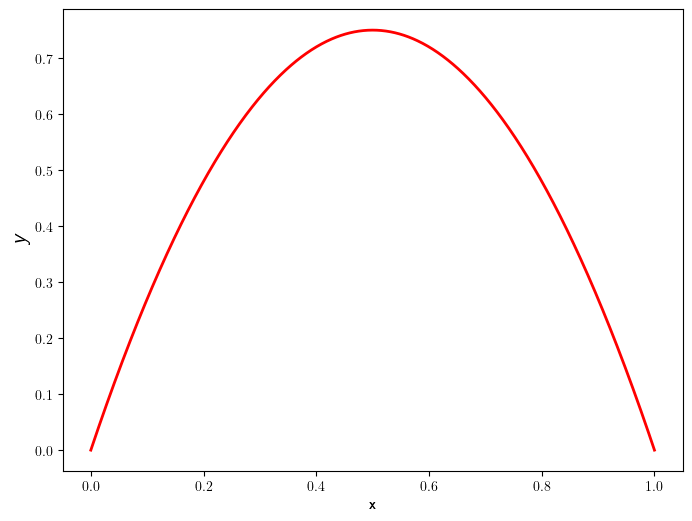

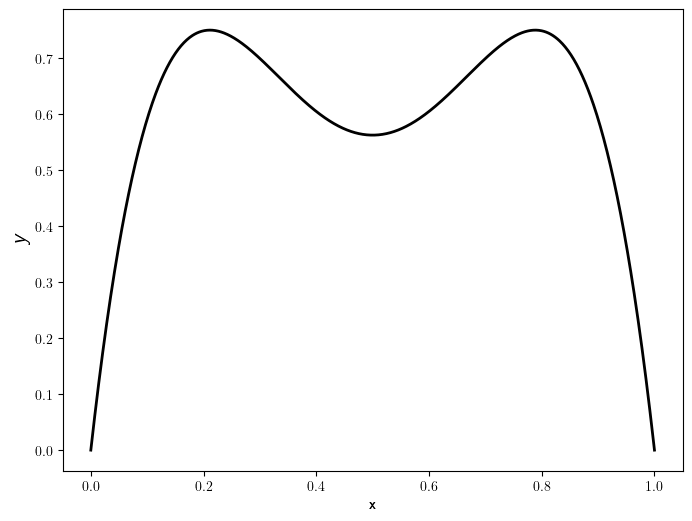

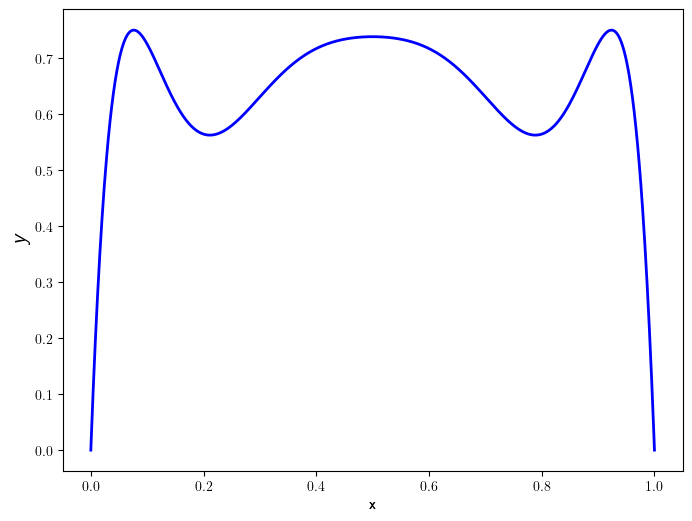

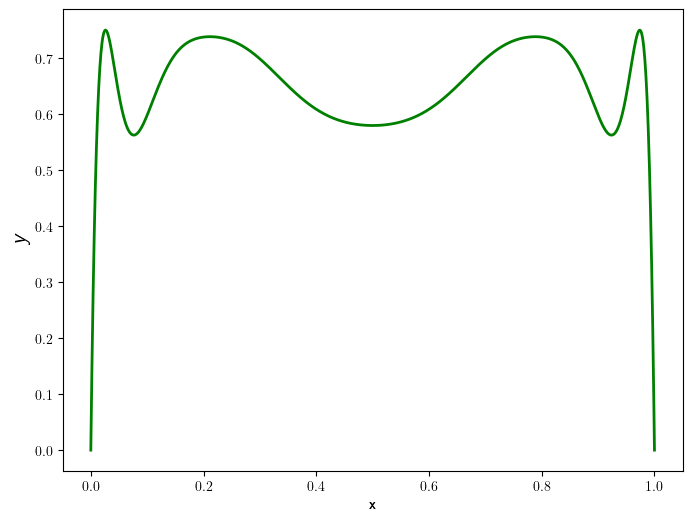

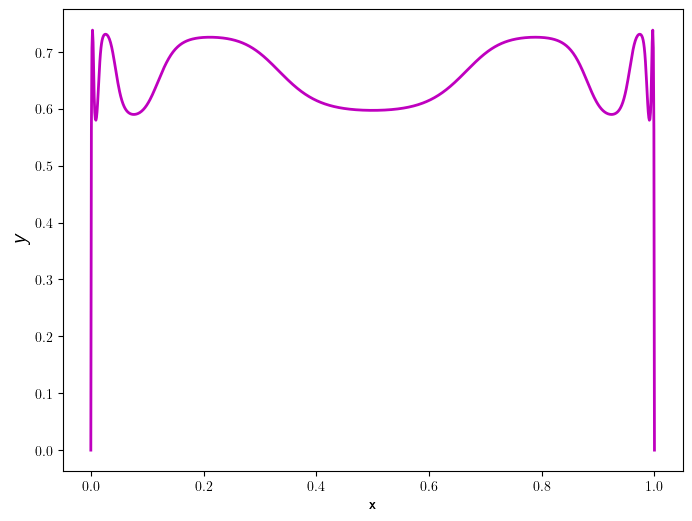

In [19]:
# Import required libraries
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Enable LaTeX rendering in matplotlib labels
matplotlib.rcParams['text.usetex'] = True


# ------------------------------------------------
# Define Logistic Map Function
# f(x) = 3x(1 - x)
# ------------------------------------------------
def f(x):
    return 3 * x * (1 - x)


# ------------------------------------------------
# Generate Input Values
# ------------------------------------------------
x = np.linspace(0, 1, 1000)  # 1000 evenly spaced points between 0 and 1


# ------------------------------------------------
# Compute Iterations of the Function
# ------------------------------------------------
y0 = f(x)      # first iteration
y1 = f(y0)     # second iteration
y2 = f(y1)     # third iteration
y3 = f(y2)     # fourth iteration

# deeper nested composition
y4 = f(f(f(f(y3))))


# ------------------------------------------------
# Store Results for Easier Plotting
# ------------------------------------------------
results = [y0, y1, y2, y3, y4]
colors = ['r', 'k', 'b', 'g', 'm']


# ------------------------------------------------
# Plot Each Iteration
# ------------------------------------------------
for i, y in enumerate(results):

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(x, y, color=colors[i], linewidth=2.0)

    # Axis labels with LaTeX formatting
    ax.set_xlabel(r'\textbf{x}')
    ax.set_ylabel(r'\textit{y}', fontsize=16)

    # Optional title (currently commented)
    # ax.set_title(r'$f(x) = 3x(1-x)$', fontsize=16)

    plt.show()
    

# RNN for Sine Wave in PyTorch

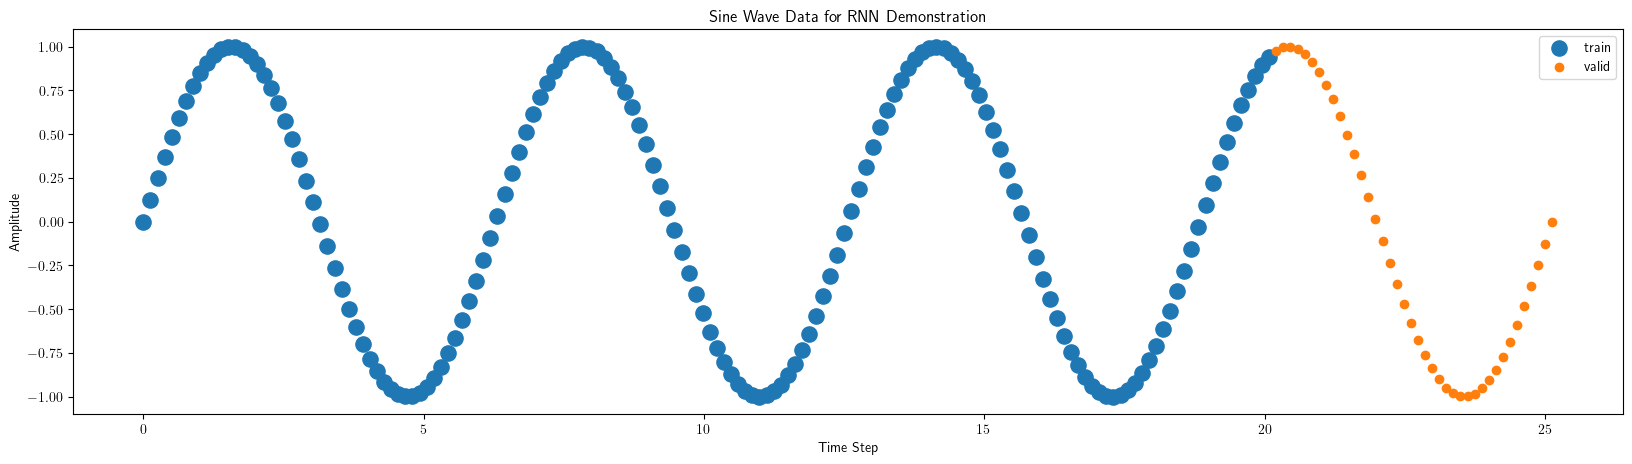

Shape of train_y:
torch.Size([159])


In [20]:
# ------------------------------------------------
# Import Required Libraries
# ------------------------------------------------
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt


# ------------------------------------------------
# Set Random Seeds for Reproducibility
# ------------------------------------------------
torch.manual_seed(2448)
np.random.seed(2448)


# Display plots inside Jupyter Notebook
%matplotlib inline


# ------------------------------------------------
# Generate Sinusoidal Sequence Data
# This function creates a sine wave and prepares
# training input-output pairs for sequence modeling.
# ------------------------------------------------
def generate_sin_wave(train_len, valid_len):
    """
    Generate sine-wave data for RNN training and validation.

    Parameters
    ----------
    train_len : int
        Number of training time steps
    valid_len : int
        Number of validation time steps

    Returns
    -------
    data : numpy.ndarray
        Full sine-wave sequence
    time_steps : numpy.ndarray
        Time values corresponding to the sine-wave data
    train_x : torch.Tensor
        Training input sequence, reshaped for RNN input
        Shape: (sequence_length, batch_size, input_size)
    train_y : torch.Tensor
        Training target values
    """

    # Create evenly spaced time points
    time_steps = np.linspace(0, 8 * np.pi, train_len + valid_len)

    # Generate sine-wave values
    data = np.sin(time_steps)

    # Prepare training inputs and targets
    # Input at time t, target at time t+1
    xs = data[:train_len - 1]
    ys = data[1:train_len]

    # Reshape input for RNN:
    # (sequence_length, batch_size, input_size)
    train_x = torch.tensor(xs, dtype=torch.float32).view(-1, 1, 1)

    # Target values
    train_y = torch.tensor(ys, dtype=torch.float32)

    return data, time_steps, train_x, train_y


# ------------------------------------------------
# Define Sequence Lengths
# ------------------------------------------------
seq_length = 200
portion_train = 0.8   # 80% training data

train_len = int(seq_length * portion_train)
valid_len = seq_length - train_len


# ------------------------------------------------
# Generate Dataset
# ------------------------------------------------
data, time_steps, train_x, train_y = generate_sin_wave(train_len, valid_len)


# ------------------------------------------------
# Plot Training and Validation Data
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 5))

# Training points
ax.scatter(
    time_steps[:train_len],
    data[:train_len],
    s=120,
    label="train"
)

# Validation points
ax.scatter(
    time_steps[train_len:],
    data[train_len:],
    label="valid"
)

ax.set_xlabel("Time Step")
ax.set_ylabel("Amplitude")
ax.set_title("Sine Wave Data for RNN Demonstration")
ax.legend()

plt.show()


# ------------------------------------------------
# Display Target Tensor Shape
# ------------------------------------------------
print("Shape of train_y:")
print(train_y.shape)

<div>
<img src="rnn.png" 
   width="750" height="200" style="margin: 5px auto; display: block; position: relative; left: -10px; bottom: 10px" />
</div>

Epoch 0: loss = 0.753947
Epoch 50: loss = 0.003085
Epoch 100: loss = 0.000415
Epoch 150: loss = 0.000349
Epoch 200: loss = 0.000376
Epoch 250: loss = 0.000030
Epoch 300: loss = 0.002075
Epoch 350: loss = 0.000015
Epoch 400: loss = 0.000009
Epoch 450: loss = 0.000009


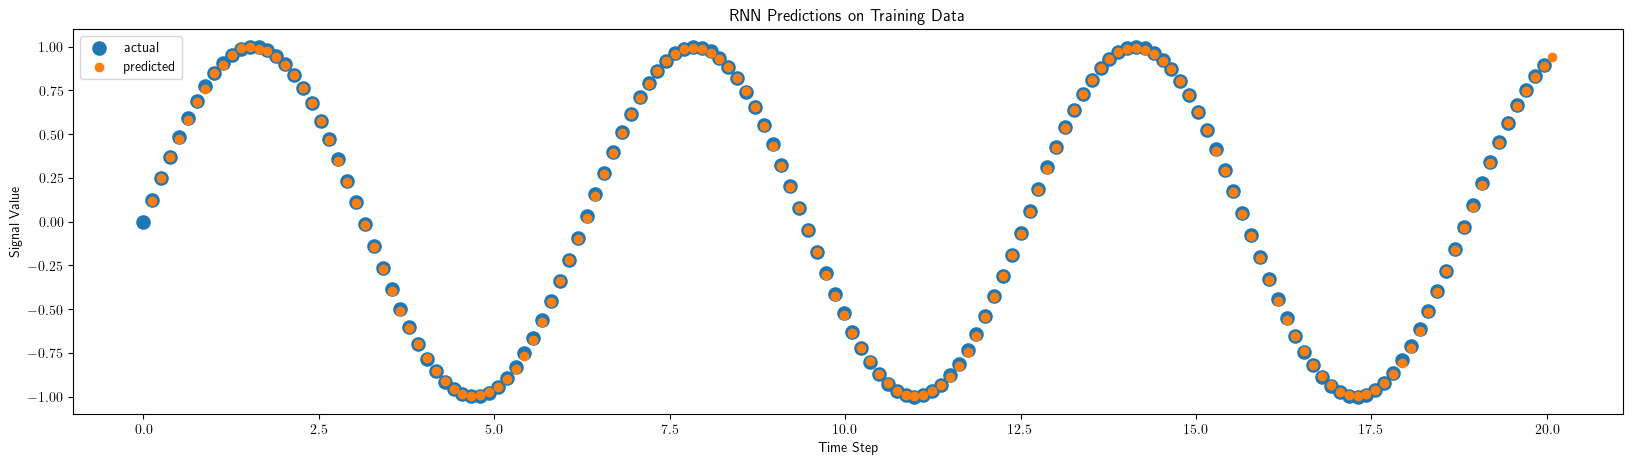

In [21]:
# ------------------------------------------------
# Define a Custom RNN Cell
# ------------------------------------------------
class RNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        """
        A simple custom RNN cell.

        Parameters
        ----------
        input_size : int
            Number of input features at each time step
        hidden_size : int
            Number of hidden units in the RNN cell
        """
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        # Input-to-hidden weights
        self.U = nn.Parameter(torch.randn(input_size, hidden_size))

        # Hidden-to-hidden weights
        self.W = nn.Parameter(torch.randn(hidden_size, hidden_size))

        # Bias term
        self.b = nn.Parameter(torch.randn(hidden_size))

    def forward(self, x_t, h_prev):
        """
        Compute the hidden state for one time step.

        Parameters
        ----------
        x_t : torch.Tensor
            Input at the current time step
            Shape: (batch_size, input_size)
        h_prev : torch.Tensor
            Hidden state from the previous time step
            Shape: (batch_size, hidden_size)

        Returns
        -------
        torch.Tensor
            Updated hidden state
        """
        # Linear transformation + nonlinear activation
        a_t = torch.mm(x_t, self.U) + torch.mm(h_prev, self.W) + self.b
        h_t = torch.sigmoid(a_t)

        return h_t


# ------------------------------------------------
# Define the Full RNN Model
# ------------------------------------------------
class SimpleRNN(nn.Module):
    def __init__(self, input_dim, hidden_size):
        """
        A simple RNN model using a custom RNN cell
        followed by a linear output layer.

        Parameters
        ----------
        input_dim : int
            Number of input features
        hidden_size : int
            Number of hidden units
        """
        super().__init__()

        self.hidden_size = hidden_size
        self.rnn_cell = RNNCell(input_dim, hidden_size)

        # Maps hidden state to a single output value
        self.output_layer = nn.Linear(hidden_size, 1)

    def init_hidden(self):
        """
        Initialize the hidden state with zeros.

        Returns
        -------
        torch.Tensor
            Initial hidden state of shape (1, hidden_size)
        """
        return torch.zeros(1, self.hidden_size)

    def forward(self, X, h=None):
        """
        Process a sequence through the RNN.

        Parameters
        ----------
        X : torch.Tensor
            Input sequence
            Shape: (sequence_length, batch_size, input_dim)
        h : torch.Tensor, optional
            Initial hidden state

        Returns
        -------
        outputs : torch.Tensor
            Predicted outputs for each time step
        h : torch.Tensor
            Final hidden state
        """
        h = self.init_hidden() if h is None else h
        outputs = []

        # Iterate through the sequence one time step at a time
        for x_t in X:
            h = self.rnn_cell(x_t, h)
            y_t = self.output_layer(h)
            outputs.append(y_t)

        return torch.stack(outputs), h


# ------------------------------------------------
# Model Hyperparameters
# ------------------------------------------------
hidden_size = 40
learning_rate = 0.01
epochs = 500


# ------------------------------------------------
# Create Model, Loss Function, and Optimizer
# ------------------------------------------------
model = SimpleRNN(input_dim=1, hidden_size=hidden_size)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


# ------------------------------------------------
# Train the Model
# ------------------------------------------------
for epoch in range(epochs):
    optimizer.zero_grad()

    # Forward pass
    output, _ = model(train_x)

    # Compute loss
    loss = criterion(output.view(-1), train_y)

    # Backpropagation
    loss.backward()
    optimizer.step()

    # Print progress every 50 epochs
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.6f}")


# ------------------------------------------------
# Make Predictions on Training Data
# ------------------------------------------------
def make_predictions_train(model, train_x):
    """
    Generate predictions for the training sequence.

    Parameters
    ----------
    model : nn.Module
        Trained RNN model
    train_x : torch.Tensor
        Training input sequence

    Returns
    -------
    predictions : list
        Predicted values for each time step
    hidden_prev : torch.Tensor
        Final hidden state
    """
    predictions = []
    hidden_prev = None

    for i in range(train_x.shape[0]):
        # Select one time step
        input_data = train_x[i].view(1, 1, 1)

        # Predict next value using previous hidden state
        pred, hidden_prev = model(input_data, hidden_prev)

        # Store scalar prediction
        predictions.append(pred.detach().numpy()[0][0][0])

    return predictions, hidden_prev


# Generate predictions
predictions_train, hidden_prev = make_predictions_train(model, train_x)


# ------------------------------------------------
# Plot Actual vs Predicted Values
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 5))

# Actual training data
ax.scatter(
    time_steps[:train_len - 1],
    data[:train_len - 1],
    s=90,
    label="actual"
)

# Predicted values
ax.scatter(
    time_steps[1:train_len],
    predictions_train,
    label="predicted"
)

ax.set_xlabel("Time Step")
ax.set_ylabel("Signal Value")
ax.set_title("RNN Predictions on Training Data")
ax.legend()

plt.show()

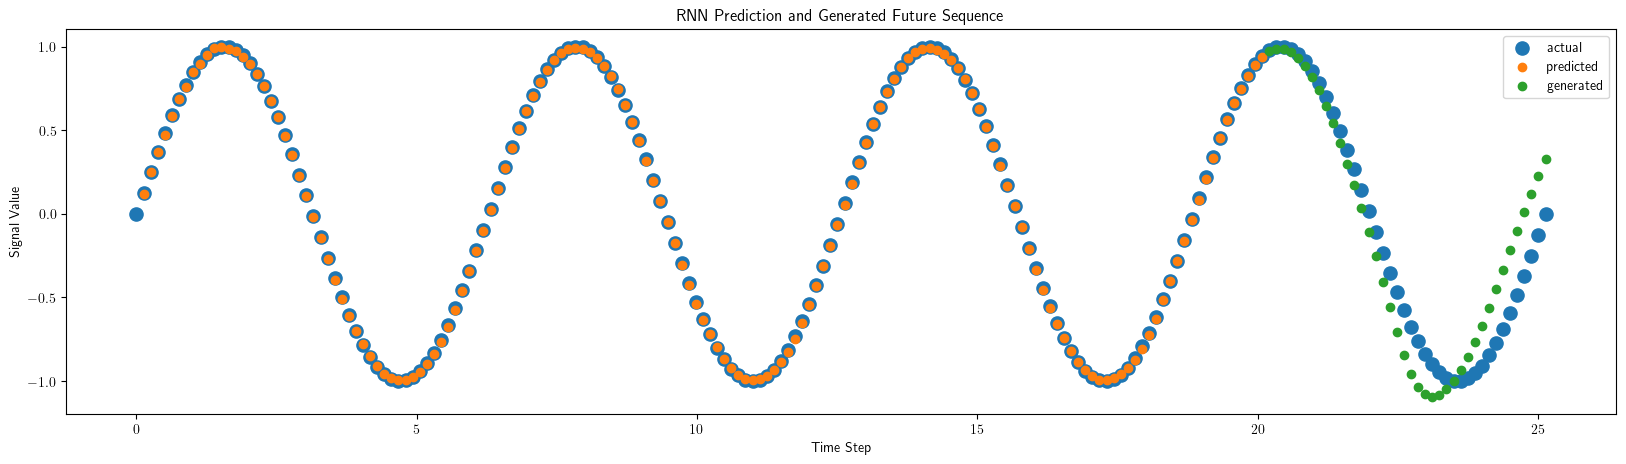

In [22]:
# ------------------------------------------------
# Generate Future Sequence Using the Trained RNN
# ------------------------------------------------
def generate_unseen_sequence(model, length, starting_point, hidden_state):
    """
    Generate future predictions using the trained RNN model.

    Parameters
    ----------
    model : nn.Module
        Trained RNN model
    length : int
        Number of future time steps to generate
    starting_point : float
        Last known value used as the initial input
    hidden_state : torch.Tensor
        Hidden state from the previous sequence

    Returns
    -------
    predicts : list
        Generated future predictions
    """

    predictions = []

    # Prepare the first input value
    input_data = torch.tensor(starting_point, dtype=torch.float32).view(1, 1, 1)

    # Generate sequence recursively
    for _ in range(length):

        # Predict next value
        pred, hidden_state = model(input_data, hidden_state)

        # Store prediction
        predictions.append(pred.detach().numpy()[0][0][0])

        # Use predicted value as the next input
        input_data = pred

    return predictions


# ------------------------------------------------
# Generate Future Values for Validation Region
# ------------------------------------------------
generated_points = generate_unseen_sequence(
    model,
    valid_len,
    starting_point=predictions_train[-1],
    hidden_state=hidden_prev
)


# Combine training predictions and generated future values
predictions = predictions_train + generated_points


# ------------------------------------------------
# Plot Actual Data vs Predicted vs Generated Values
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 5))

# Actual sine wave
ax.scatter(
    time_steps,
    data,
    s=90,
    label="actual"
)

# Predictions on training region
ax.scatter(
    time_steps[1:train_len],
    predictions[:train_len - 1],
    label="predicted"
)

# Generated future sequence
ax.scatter(
    time_steps[train_len:],
    predictions[train_len - 1:],
    label="generated"
)

ax.set_xlabel("Time Step")
ax.set_ylabel("Signal Value")
ax.set_title("RNN Prediction and Generated Future Sequence")
ax.legend()

plt.show()

# LSTM for Sine Wave in TensorFlow

Epoch 1/20
31/31 [==============================] - 2s 5ms/step - loss: 0.4276
Epoch 2/20
31/31 [==============================] - 0s 4ms/step - loss: 0.2403
Epoch 3/20
31/31 [==============================] - 0s 5ms/step - loss: 0.1443
Epoch 4/20
31/31 [==============================] - 0s 5ms/step - loss: 0.0742
Epoch 5/20
31/31 [==============================] - 0s 4ms/step - loss: 0.0222
Epoch 6/20
31/31 [==============================] - 0s 4ms/step - loss: 0.0037
Epoch 7/20
31/31 [==============================] - 0s 4ms/step - loss: 0.0022
Epoch 8/20
31/31 [==============================] - 0s 4ms/step - loss: 0.0018
Epoch 9/20
31/31 [==============================] - 0s 4ms/step - loss: 0.0014
Epoch 10/20
31/31 [==============================] - 0s 4ms/step - loss: 0.0012
Epoch 11/20
31/31 [==============================] - 0s 4ms/step - loss: 9.1912e-04
Epoch 12/20
31/31 [==============================] - 0s 4ms/step - loss: 7.4755e-04
Epoch 13/20
31/31 [======================

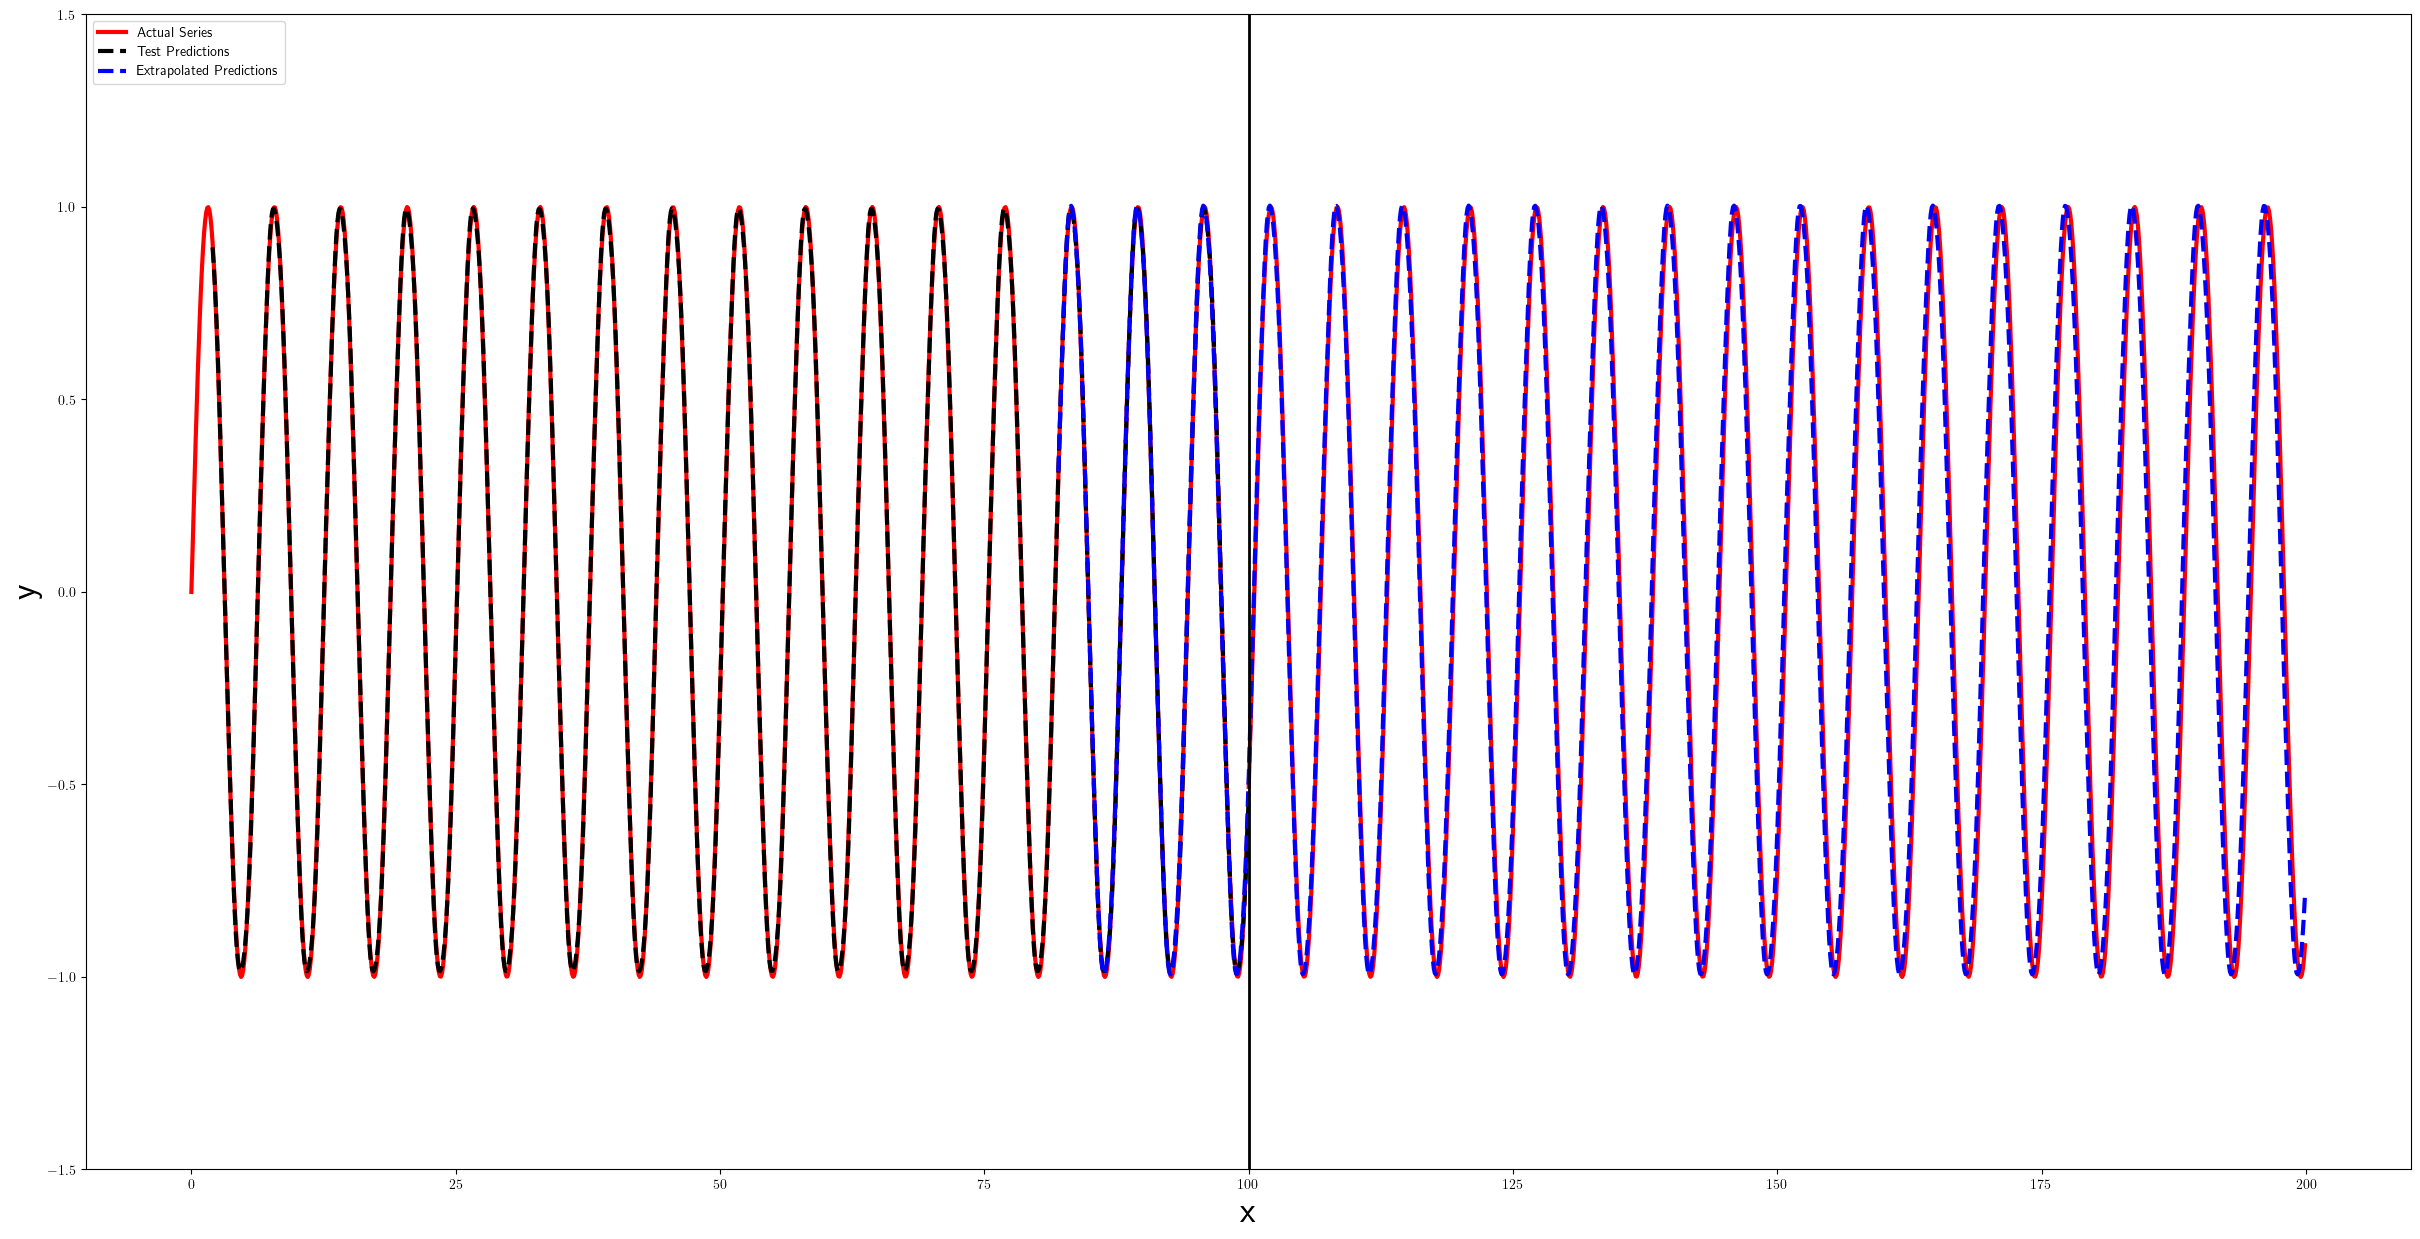

(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)
(1, 1)

In [32]:
# ------------------------------------------------
# Import Required Libraries
# ------------------------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Prepare Sequential Dataset
# ------------------------------------------------
def create_sequence_data(series, seq_length):
    """
    Convert a time series into input-output sequences
    suitable for training an LSTM.

    Parameters
    ----------
    series : numpy.ndarray
        Original time-series data
    seq_length : int
        Length of input sequence

    Returns
    -------
    X : numpy.ndarray
        Input sequences
    Y : numpy.ndarray
        Target values
    """

    X, Y = [], []
    length = len(series)

    for i in range(length):
        end_idx = i + seq_length

        # Ensure the sequence does not exceed data length
        if end_idx > length - 1:
            break

        X.append(series[i:end_idx])
        Y.append(series[end_idx])

    return np.array(X), np.array(Y)


# ------------------------------------------------
# Generate Training and Testing Data (Sine Wave)
# ------------------------------------------------
x_sin = np.arange(0, 100, 0.1)
y_sin = np.sin(x_sin)

x_test_axis = np.linspace(0, 100, 1000)
y_test_full = np.sin(x_test_axis)


# ------------------------------------------------
# Define Sequence Length
# ------------------------------------------------
seq_length = 20


# ------------------------------------------------
# Convert Data into Sequential Training Format
# ------------------------------------------------
x_train, y_train = create_sequence_data(y_sin, seq_length)
x_test_seq, y_test_seq = create_sequence_data(y_test_full, seq_length)


# ------------------------------------------------
# Reshape Data for LSTM Input
# LSTM expects input shape:
# (samples, time_steps, features)
# ------------------------------------------------
num_features = 1

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], num_features))
x_test_seq = x_test_seq.reshape((x_test_seq.shape[0], x_test_seq.shape[1], num_features))


# ------------------------------------------------
# Build LSTM Model
# ------------------------------------------------
model = Sequential()
model.add(LSTM(10, input_shape=(seq_length, num_features)))
model.add(Dense(1))
model.compile(optimizer="adam", loss="mse")


# ------------------------------------------------
# Train the Model
# ------------------------------------------------
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    verbose=1
)


# ------------------------------------------------
# Predict on Test Data
# ------------------------------------------------
y_predict = model.predict(x_test_seq, verbose=0).flatten()


# ------------------------------------------------
# Generate Future Predictions
# ------------------------------------------------
pred_x = np.arange(80, 200, 0.1)
pred_y_true = np.sin(pred_x)

results = []

# Start from the first known sequence
test_sequence = pred_y_true[:seq_length].copy()

# Recursive prediction loop
for i in range(len(pred_x) - seq_length):
    net_input = test_sequence[i:i + seq_length]
    net_input = net_input.reshape((1, seq_length, num_features))

    prediction = model.predict(net_input, verbose=0)[0, 0]

    results.append(prediction)
    test_sequence = np.append(test_sequence, prediction)

future_predictions = np.array(results)
future_x = pred_x[seq_length:seq_length + len(future_predictions)]


# ------------------------------------------------
# x-values for test predictions
# Since each input sequence of length seq_length predicts the next point,
# predictions align with x_test_axis[seq_length:]
# ------------------------------------------------
x_test_pred = x_test_axis[seq_length:seq_length + len(y_predict)]


# ------------------------------------------------
# Generate Extended True Sine Wave for Comparison
# ------------------------------------------------
x_ext = np.arange(100, 200, 0.1)
y_ext = np.sin(x_ext)


# ------------------------------------------------
# Create Plot
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(30, 15))

ax.set_xlabel("x", fontsize=26)
ax.set_ylabel("y", fontsize=26)

# Actual sine wave on known region
ax.plot(
    x_sin,
    y_sin,
    "-r",
    linewidth=3.0,
    label="Actual Series"
)

# Actual sine wave on extended region
ax.plot(
    x_ext,
    y_ext,
    "-r",
    linewidth=3.0
)

# Test predictions on [0, 100]
ax.plot(
    x_test_pred,
    y_predict,
    "--k",
    linewidth=3.0,
    label="Test Predictions"
)

# Extrapolated predictions beyond x=80
ax.plot(
    future_x,
    future_predictions,
    "--b",
    linewidth=3.0,
    label="Extrapolated Predictions"
)

# Mark boundary at x=100
ax.vlines(
    100,
    -1.5,
    1.5,
    colors="black",
    linestyles="solid",
    linewidth=2.0
)

ax.set_ylim(-1.5, 1.5)
ax.legend(loc="upper left")
plt.show()

In [31]:
# ------------------------------------------------
# Generate Extended True Sine Wave for Comparison
# ------------------------------------------------
x_true = np.arange(0, 200, 0.1)
y_true = np.sin(x_true)

# Boundary between known region and extrapolation
split_x = 100

# Known/test region and future region
x_known = x_true[x_true < split_x]
y_known = y_true[x_true < split_x]

x_ext = x_true[x_true >= split_x]
y_ext = y_true[x_true >= split_x]

# ------------------------------------------------
# Flatten model predictions for plotting
# ------------------------------------------------
y_predict = np.asarray(y_predict).flatten()
test_y = np.asarray(test_y).flatten()

# ------------------------------------------------
# Build x-values for predictions
# ------------------------------------------------
# Test predictions are assumed to correspond to the end of the known region
x_test_pred = x_known[-len(y_predict):]

# Extrapolated predictions are assumed to start at x = 100
x_extrap = x_ext[:len(test_y)]

# ------------------------------------------------
# Create Plot
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(30, 15))

ax.set_xlabel("x", fontsize=26)
ax.set_ylabel("y", fontsize=26)

# ------------------------------------------------
# Plot Actual Sine Wave
# ------------------------------------------------
ax.plot(
    x_known,
    y_known,
    "-r",
    linewidth=3.0,
    label="Actual Series"
)

ax.plot(
    x_ext,
    y_ext,
    "-r",
    linewidth=3.0
)

# ------------------------------------------------
# Plot Test Predictions
# ------------------------------------------------
ax.plot(
    x_test_pred,
    y_predict,
    "--k",
    linewidth=3.0,
    label="Test Series"
)

# ------------------------------------------------
# Plot Extrapolated Predictions
# ------------------------------------------------
ax.plot(
    x_extrap,
    test_y[:len(x_extrap)],
    "--b",
    linewidth=3.0,
    label="Extrapolated"
)

# ------------------------------------------------
# Mark the boundary between known and extrapolated region
# ------------------------------------------------
ax.vlines(
    split_x,
    -1.5,
    1.5,
    colors="black",
    linestyles="solid",
    linewidth=2.0
)

ax.set_ylim(-1.5, 1.5)
ax.legend(loc="upper left")
plt.show()

NameError: name 'test_y' is not defined

# LSTM for Sine wave in TensorFlow using TimeSerisGenerator

In [14]:
from keras.preprocessing.sequence import TimeseriesGenerator
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt



x_train = np.arange(0, 100, 0.1)
y_train = np.sin(x_sin)
x_test = np.linspace(100, 200, 1000, endpoint=True)
y_test = np.sin(x_test)
num_features = 1

seq_train = np.reshape(y_train, (len(y_train), num_features))
seq_test =  np.reshape(y_test, (len(y_train), num_features))

seq_length = 20

seq_train_generator =  TimeseriesGenerator(seq_train, seq_train, length=seq_length, sampling_rate = 1,\
                                           stride = 1, batch_size = 5)
seq_test_generator =  TimeseriesGenerator(seq_test, seq_test, length=seq_length, sampling_rate = 1,\
                                           stride = 1, batch_size = 5)


model = Sequential()
model.add(LSTM(10, input_shape = (seq_length, num_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')


h = model.fit(seq_train_generator, epochs=20, verbose=1)
y_predict = model.predict(seq_test_generator)

Epoch 1/20
196/196 [==============================] - 2s 4ms/step - loss: 0.1793
Epoch 2/20
196/196 [==============================] - 1s 4ms/step - loss: 0.0308
Epoch 3/20
196/196 [==============================] - 1s 4ms/step - loss: 0.0022
Epoch 4/20
196/196 [==============================] - 1s 4ms/step - loss: 6.1547e-04
Epoch 5/20
196/196 [==============================] - 1s 4ms/step - loss: 3.4028e-04
Epoch 6/20
196/196 [==============================] - 1s 4ms/step - loss: 1.8422e-04
Epoch 7/20
196/196 [==============================] - 1s 4ms/step - loss: 1.0904e-04
Epoch 8/20
196/196 [==============================] - 1s 4ms/step - loss: 1.0224e-04
Epoch 9/20
196/196 [==============================] - 1s 4ms/step - loss: 7.6052e-05
Epoch 10/20
196/196 [==============================] - 1s 4ms/step - loss: 7.3023e-05
Epoch 11/20
196/196 [==============================] - 1s 4ms/step - loss: 5.2972e-05
Epoch 12/20
196/196 [==============================] - 1s 4ms/step - loss: 

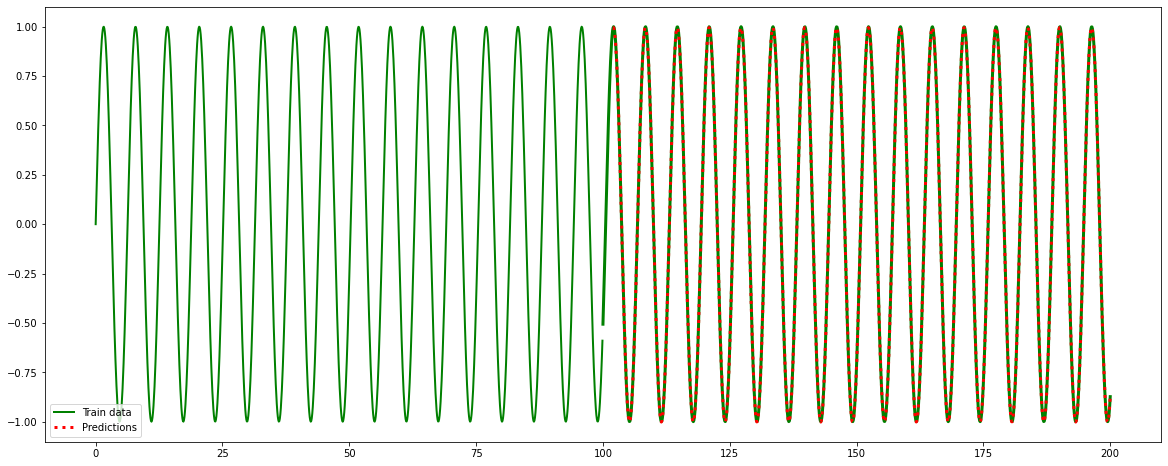

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(20, 8))
ax.plot(x_train,y_train, c="g", lw=2, label='Train data')
ax.plot(x_test,y_test, lw=3, c="g")
ax.plot(x_test[seq_length:],y_predict, lw=3, c='r',linestyle = ':', label='Predictions')
ax.legend(loc="lower left")
plt.show();

In [41]:
ext = list()
st_batch    = y_test[:seq_length].reshape((1,seq_length, num_features))
ct_batch = st_batch
start_seq = ct_batch.reshape((seq_length,1))

num_sample_pred = 800
# extrapolate next 160 values
for i in range(num_sample_pred):
    predicted_value = model.predict(ct_batch)[0]
    ext.append(predicted_value) 
    ct_batch = np.append(ct_batch[:,1:,:],[[predicted_value]],axis=1)
    


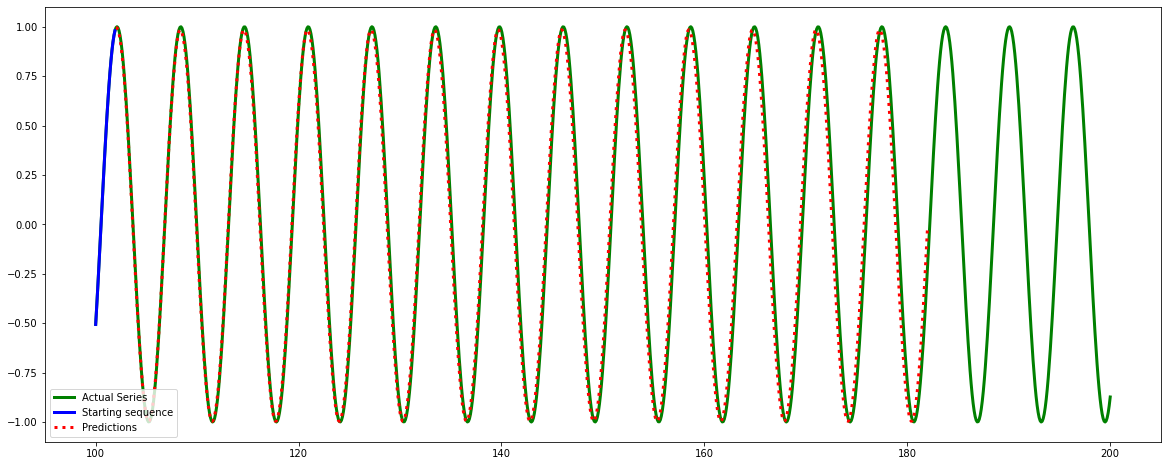

In [42]:
ext_np = np.array(ext)
seq_list = x_test[:seq_length]
fig, ax = plt.subplots(1, 1, figsize=(20, 8))
ax.plot(x_test,y_test, lw=3, c="g", label="Actual Series")
ax.plot(seq_list, start_seq, lw=3, c="b", label="Starting sequence")
ax.plot(x_test[seq_length:num_sample_pred + seq_length],ext_np, lw=3, c='r',linestyle = ':', label='Predictions')
ax.legend(loc="lower left")
plt.show();